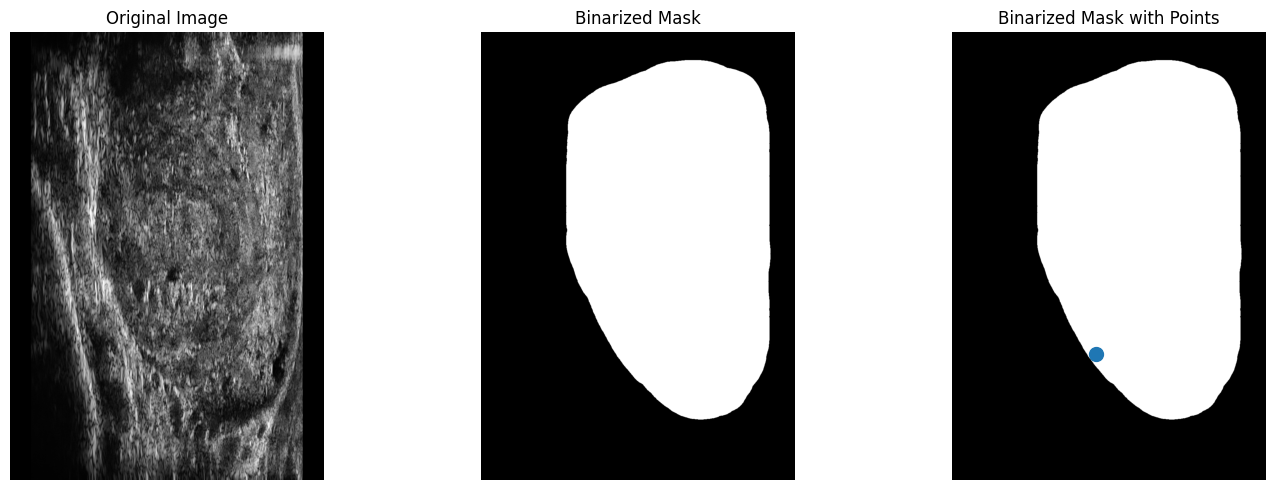

In [15]:

import os
import pandas as pd
import cv2
import torch
import torch.nn.utils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import random
# 用的环境python 3.10.14
# 获取当前运行时的路径 兴趣点是蓝色的点，是随机生成的
current_dir = os.getcwd()

# 设置 images 和 masks 的目录相对于运行时的路径
data_dir = os.path.join(current_dir, "Micro_Prostate_Dataset")
images_dir = os.path.join("")
masks_dir = os.path.join("")


# 加载 train.csv 文件
train_csv_path = os.path.join(data_dir, "TrainDataset.csv")
train_df = pd.read_csv(train_csv_path)


# Split the data into two halves: one for training and one for testing
train_df, test_df = train_test_split(train_df, test_size=0.2, random_state=42)

# Prepare the training data list
train_data = []
for index, row in train_df.iterrows():
   image_name = row['ImageId']
   mask_name = row['MaskId']

   # Append image and corresponding mask paths
   train_data.append({
       "image": os.path.join(images_dir, image_name),
       "annotation": os.path.join(masks_dir, mask_name)
   })

# Prepare the testing data list (if needed for inference or evaluation later)
test_data = []
for index, row in test_df.iterrows():
   image_name = row['ImageId']
   mask_name = row['MaskId']

   # Append image and corresponding mask paths
   test_data.append({
       "image": os.path.join(images_dir, image_name),
       "annotation": os.path.join(masks_dir, mask_name)
   })

def read_batch(data, visualize_data=False):
   # Select a random entry
   ent = data[np.random.randint(len(data))]

   # Get full paths
   Img = cv2.imread(ent["image"])[..., ::-1]  # Convert BGR to RGB
   ann_map = cv2.imread(ent["annotation"], cv2.IMREAD_GRAYSCALE)  # Read annotation as grayscale

   if Img is None or ann_map is None:
       print(f"Error: Could not read image or mask from path {ent['image']} or {ent['annotation']}")
       return None, None, None, 0

   # Resize image and mask
   r = np.min([3848 / Img.shape[1], 5488 / Img.shape[0]])  # Scaling factor
   Img = cv2.resize(Img, (int(Img.shape[1] * r), int(Img.shape[0] * r)))
   ann_map = cv2.resize(ann_map, (int(ann_map.shape[1] * r), int(ann_map.shape[0] * r)), interpolation=cv2.INTER_NEAREST)

      ### Continuation of read_batch() ###

   # Initialize a single binary mask
   binary_mask = np.zeros_like(ann_map, dtype=np.uint8)
   points = []

   # Get binary masks and combine them into a single mask
   inds = np.unique(ann_map)[1:]  # Skip the background (index 0)
   for ind in inds:
       mask = (ann_map == ind).astype(np.uint8)  # Create binary mask for each unique index
       binary_mask = np.maximum(binary_mask, mask)  # Combine with the existing binary mask

   # Erode the combined binary mask to avoid boundary points
   eroded_mask = cv2.erode(binary_mask, np.ones((5, 5), np.uint8), iterations=1)

   # Get all coordinates inside the eroded mask and choose a random point
   coords = np.argwhere(eroded_mask > 0)
   if len(coords) > 0:
       for _ in inds:  # Select as many points as there are unique labels
           yx = np.array(coords[np.random.randint(len(coords))])
           points.append([yx[1], yx[0]])

   points = np.array(points)
        ### Continuation of read_batch() ###

   if visualize_data:
        # Plotting the images and points
        plt.figure(figsize=(15, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.title('Original Image')
        plt.imshow(Img)
        plt.axis('off')

        # Segmentation Mask (binary_mask)
        plt.subplot(1, 3, 2)
        plt.title('Binarized Mask')
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')

        # Mask with Points in Different Colors
        plt.subplot(1, 3, 3)
        plt.title('Binarized Mask with Points')
        plt.imshow(binary_mask, cmap='gray')

        # Plot points in different colors
        colors = list(mcolors.TABLEAU_COLORS.values())
        for i, point in enumerate(points):
            plt.scatter(point[0], point[1], c=colors[i % len(colors)], s=100, label=f'Point {i+1}')  # Corrected to plot y, x order

        # plt.legend()
        plt.axis('off')

        plt.tight_layout()
        plt.show()

   binary_mask = np.expand_dims(binary_mask, axis=-1)  # Now shape is (1024, 1024, 1)
   binary_mask = binary_mask.transpose((2, 0, 1))
   points = np.expand_dims(points, axis=1)

    # Return the image, binarized mask, points, and number of masks
   return Img, binary_mask, points, len(inds)

# Visualize the data
Img1, masks1, points1, num_masks = read_batch(train_data, visualize_data=True)


In [16]:
sam2_checkpoint = "sam2_hiera_large.pt"  # @param ["sam2_hiera_tiny.pt", "sam2_hiera_small.pt", "sam2_hiera_base_plus.pt", "sam2_hiera_large.pt"]
model_cfg = "configs/sam2/sam2_hiera_l.yaml" # @param ["sam2_hiera_t.yaml", "sam2_hiera_s.yaml", "sam2_hiera_b+.yaml", "sam2_hiera_l.yaml"]

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device="cuda")
predictor = SAM2ImagePredictor(sam2_model)


In [17]:
# Train mask decoder.
predictor.model.sam_mask_decoder.train(True)

# Train prompt encoder.
predictor.model.sam_prompt_encoder.train(True)

# Configure optimizer.
optimizer=torch.optim.AdamW(params=predictor.model.parameters(),lr=0.0001,weight_decay=1e-4) #1e-5, weight_decay = 4e-5

# Mix precision.
scaler = torch.cuda.amp.GradScaler()

# No. of steps to train the model.
NO_OF_STEPS = 8000 # @param 

# Fine-tuned model name.
FINE_TUNED_MODEL_NAME = "fine_tuned_sam2"


In [18]:
# Initialize scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.2) # 500 , 250, gamma = 0.1
accumulation_steps = 4  # Number of steps to accumulate gradients before updating

# 用于存储最高的10个IoU和相应的step
top_ious = []

for step in range(1, NO_OF_STEPS + 1):
    with torch.cuda.amp.autocast():
        image, mask, input_point, num_masks = read_batch(train_data, visualize_data=False)
        if image is None or mask is None or num_masks == 0:
            continue

        input_label = np.ones((num_masks, 1))
        if not isinstance(input_point, np.ndarray) or not isinstance(input_label, np.ndarray):
            continue

        if input_point.size == 0 or input_label.size == 0:
            continue

        predictor.set_image(image)
        mask_input, unnorm_coords, labels, unnorm_box = predictor._prep_prompts(input_point, input_label, box=None, mask_logits=None, normalize_coords=True)
        if unnorm_coords is None or labels is None or unnorm_coords.shape[0] == 0 or labels.shape[0] == 0:
            continue

        sparse_embeddings, dense_embeddings = predictor.model.sam_prompt_encoder(
            points=(unnorm_coords, labels), boxes=None, masks=None,
        )

        batched_mode = unnorm_coords.shape[0] > 1
        high_res_features = [feat_level[-1].unsqueeze(0) for feat_level in predictor._features["high_res_feats"]]
        low_res_masks, prd_scores, _, _ = predictor.model.sam_mask_decoder(
            image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
            image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=True,
            repeat_image=batched_mode,
            high_res_features=high_res_features,
        )
        prd_masks = predictor._transforms.postprocess_masks(low_res_masks, predictor._orig_hw[-1])

        gt_mask = torch.tensor(mask.astype(np.float32)).cuda()
        prd_mask = torch.sigmoid(prd_masks[:, 0])
        seg_loss = (-gt_mask * torch.log(prd_mask + 0.000001) - (1 - gt_mask) * torch.log((1 - prd_mask) + 0.00001)).mean()

        inter = (gt_mask * (prd_mask > 0.5)).sum(1).sum(1)
        iou = inter / (gt_mask.sum(1).sum(1) + (prd_mask > 0.5).sum(1).sum(1) - inter)
        score_loss = torch.abs(prd_scores[:, 0] - iou).mean()
        loss = seg_loss + score_loss * 0.05

        # Apply gradient accumulation
        loss = loss / accumulation_steps
        scaler.scale(loss).backward()

        # Clip gradients
        torch.nn.utils.clip_grad_norm_(predictor.model.parameters(), max_norm=1.0)

        if step % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            predictor.model.zero_grad()

        # Update scheduler
        scheduler.step()

        
        mean_iou = np.mean(iou.cpu().detach().numpy())

        if step % 200 == 0:
            # 这个是step200第一部分生成的IoU
            print("Step " + str(step) + ":\t", "Accuracy (IoU) = ", mean_iou)
            FINE_TUNED_MODEL = "./sam2-fine-tuned-checkpoint/large_4x/" + FINE_TUNED_MODEL_NAME  + "_" + str(step) + ".torch"
            torch.save(predictor.model.state_dict(), FINE_TUNED_MODEL)
            # 记录并保存模型
            top_ious.append((mean_iou, step))
            top_ious = sorted(top_ious, reverse=True, key=lambda x: x[0])[:10]  # 保留最高的10个IoU记录

        if step == 1:
            mean_iou = 0

        mean_iou = mean_iou * 0.99 + 0.01 * np.mean(iou.cpu().detach().numpy())



/home/wang/anaconda3/envs/sam2/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:216: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Step 400:	 Accuracy (IoU) =  0.5271551
Step 800:	 Accuracy (IoU) =  0.5259796
Step 1000:	 Accuracy (IoU) =  0.20284604
Step 1200:	 Accuracy (IoU) =  0.9342598
Step 1400:	 Accuracy (IoU) =  0.80404246
Step 1600:	 Accuracy (IoU) =  0.9198078
Step 1800:	 Accuracy (IoU) =  0.6347379
Step 2000:	 Accuracy (IoU) =  0.7376055
Step 2200:	 Accuracy (IoU) =  0.9058258
Step 2400:	 Accuracy (IoU) =  0.9258369
Step 2600:	 Accuracy (IoU) =  0.7573901
Step 2800:	 Accuracy (IoU) =  0.8579437
Step 3000:	 Accuracy (IoU) =  0.9105595
Step 3200:	 Accuracy (IoU) =  0.84663534
Step 3400:	 Accuracy (IoU) =  0.9138471
Step 3800:	 Accuracy (IoU) =  0.87540025
Step 4000:	 Accuracy (IoU) =  0.8655315
Step 4400:	 Accuracy (IoU) =  0.91411656
Step 4600:	 Accuracy (IoU) =  0.7508757
Step 4800:	 Accuracy (IoU) =  0.84720874
Step 5000:	 Accuracy (IoU) =  0.922593
Step 5400:	 Accuracy (IoU) =  0.6857034
Step 5600:	 Accuracy (IoU) =  0.8231674
Step 5800:	 Accuracy (IoU) =  0.6276034
Step 6000:	 Accuracy (IoU) =  0.86152

In [19]:
print("Top 10 IoUs and corresponding steps:")
for i, (iou_val, step_val) in enumerate(top_ious):
    # 这个是rank1第2部分生成的IoU
    print(f"Rank {i+1}: IoU = {iou_val:.4f} at Step = {step_val}")

Top 10 IoUs and corresponding steps:
Rank 1: IoU = 0.9343 at Step = 1200
Rank 2: IoU = 0.9258 at Step = 2400
Rank 3: IoU = 0.9226 at Step = 5000
Rank 4: IoU = 0.9198 at Step = 1600
Rank 5: IoU = 0.9141 at Step = 4400
Rank 6: IoU = 0.9138 at Step = 3400
Rank 7: IoU = 0.9106 at Step = 3000
Rank 8: IoU = 0.9058 at Step = 2200
Rank 9: IoU = 0.9040 at Step = 6600
Rank 10: IoU = 0.8990 at Step = 6200
